# Credit Scoring — Fase 1: Exploratory Data Analysis

Dataset: **Give Me Some Credit** (Kaggle)  
Target: `SeriousDlqin2yrs` — 1 si el cliente tuvo default en los siguientes 2 años  
Objetivo: entender la estructura del dataset, calidad de los datos, y poder predictivo de cada variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import missingno as msno
from pathlib import Path
from scipy import stats

# Rutas
DATA_RAW = Path('../data/raw')
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# Estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Carga del dataset y overview general

Verificamos shape, tipos de datos y uso de memoria antes de cualquier análisis.

In [2]:
df = pd.read_csv(DATA_RAW / 'cs-training.csv', index_col=0)

# Renombrar columnas problemáticas
df = df.rename(columns={
    'NumberOfTime30-59DaysPastDueNotWorse': 'late_30_59',
    'NumberOfTime60-89DaysPastDueNotWorse': 'late_60_89',
    'NumberOfTimes90DaysLate': 'late_90plus',
    'RevolvingUtilizationOfUnsecuredLines': 'revolving_util',
    'NumberOfOpenCreditLinesAndLoans': 'open_credit_lines',
    'NumberRealEstateLoansOrLines': 'real_estate_loans',
    'MonthlyIncome': 'monthly_income',
    'NumberOfDependents': 'n_dependents',
    'DebtRatio': 'debt_ratio',
    'SeriousDlqin2yrs': 'target',
})

print(f'Shape: {df.shape}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n')
display(df.dtypes.to_frame('dtype').join(df.nunique().to_frame('n_unique')))

Shape: (150000, 11)
Memoria: 14.4 MB



,dtype,n_unique
target,int64,2
revolving_util,float64,125728
age,int64,86
late_30_59,int64,16
debt_ratio,float64,114194
monthly_income,float64,13594
open_credit_lines,int64,58
late_90plus,int64,19
real_estate_loans,int64,28
late_60_89,int64,13


In [3]:
display(df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.round(3))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
target,150000.0,0.067,0.250,0.0,0.0,0.000,0.000,0.000,0.000,1.0,1.000,1.0
revolving_util,150000.0,6.048,249.755,0.0,0.0,0.000,0.030,0.154,0.559,1.0,1.093,50708.0
age,150000.0,52.295,14.772,0.0,24.0,29.000,41.000,52.000,63.000,78.0,87.000,109.0
late_30_59,150000.0,0.421,4.193,0.0,0.0,0.000,0.000,0.000,0.000,2.0,4.000,98.0
debt_ratio,150000.0,353.005,2037.819,0.0,0.0,0.004,0.175,0.367,0.868,2449.0,4979.040,329664.0
monthly_income,120269.0,6670.221,14384.674,0.0,0.0,1300.000,3400.000,5400.000,8249.000,14587.6,25000.000,3008750.0
open_credit_lines,150000.0,8.453,5.146,0.0,0.0,2.000,5.000,8.000,11.000,18.0,24.000,58.0
late_90plus,150000.0,0.266,4.169,0.0,0.0,0.000,0.000,0.000,0.000,1.0,3.000,98.0
real_estate_loans,150000.0,1.018,1.130,0.0,0.0,0.000,0.000,1.000,2.000,3.0,4.000,54.0
late_60_89,150000.0,0.240,4.155,0.0,0.0,0.000,0.000,0.000,0.000,1.0,2.000,98.0


## 2. Análisis de valores nulos

Identificamos variables con missings y su patrón. `missingno` permite ver si los nulos son aleatorios (MCAR) o tienen estructura.

In [4]:
null_summary = pd.DataFrame({
    'n_nulls': df.isnull().sum(),
    'pct_null': (df.isnull().mean() * 100).round(2)
}).query('n_nulls > 0').sort_values('pct_null', ascending=False)

print('Variables con nulos:')
display(null_summary)

Variables con nulos:


,n_nulls,pct_null
monthly_income,29731,19.82
n_dependents,3924,2.62


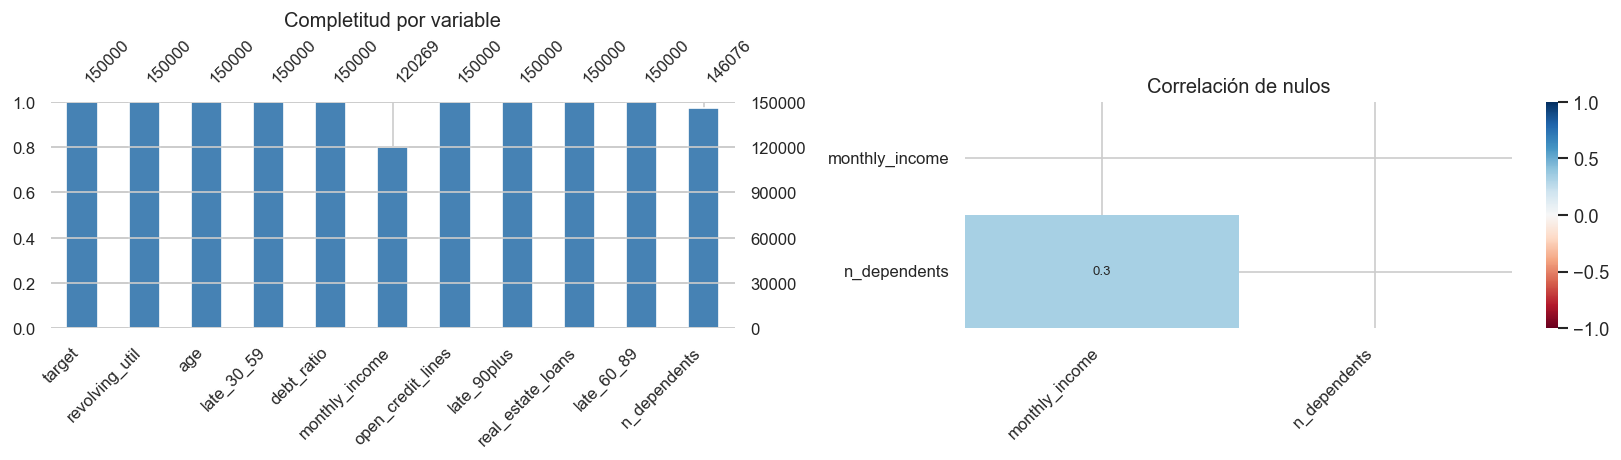

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
msno.bar(df, ax=axes[0], color='steelblue', fontsize=10)
axes[0].set_title('Completitud por variable')
msno.heatmap(df, ax=axes[1], fontsize=10)
axes[1].set_title('Correlación de nulos')
plt.tight_layout()
plt.savefig(FIGURES / '01_missing_values.png', bbox_inches='tight')
plt.show()

## 3. Distribución del target

Calculamos la tasa de default y cuantificamos el desbalanceo. Esto define la estrategia de modelado (métricas, balanceo de clases).

In [6]:
target_counts = df['target'].value_counts()
default_rate = df['target'].mean()
imbalance_ratio = target_counts[0] / target_counts[1]

print(f'Tasa de default: {default_rate:.2%}')
print(f'Ratio de desbalanceo (0:1): {imbalance_ratio:.1f}x')
display(target_counts.to_frame('count').assign(pct=target_counts / len(df) * 100))

Tasa de default: 6.68%
Ratio de desbalanceo (0:1): 14.0x


,count,pct
target,,
0,139974,93.316
1,10026,6.684


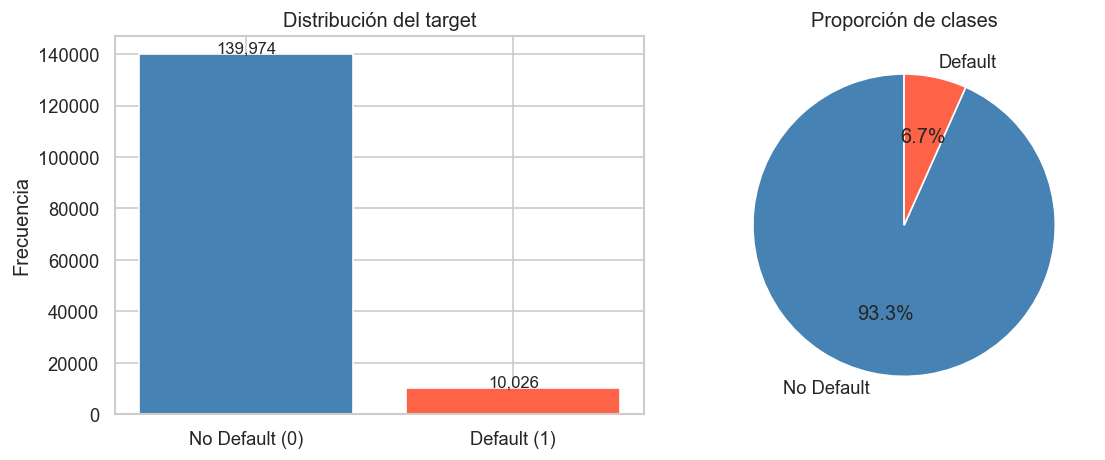

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Distribución del target')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(target_counts.values, labels=['No Default', 'Default'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig(FIGURES / '02_target_distribution.png', bbox_inches='tight')
plt.show()

## 4. Distribuciones de variables numéricas

Histogramas y boxplots para detectar asimetría, outliers extremos y rangos problemáticos.

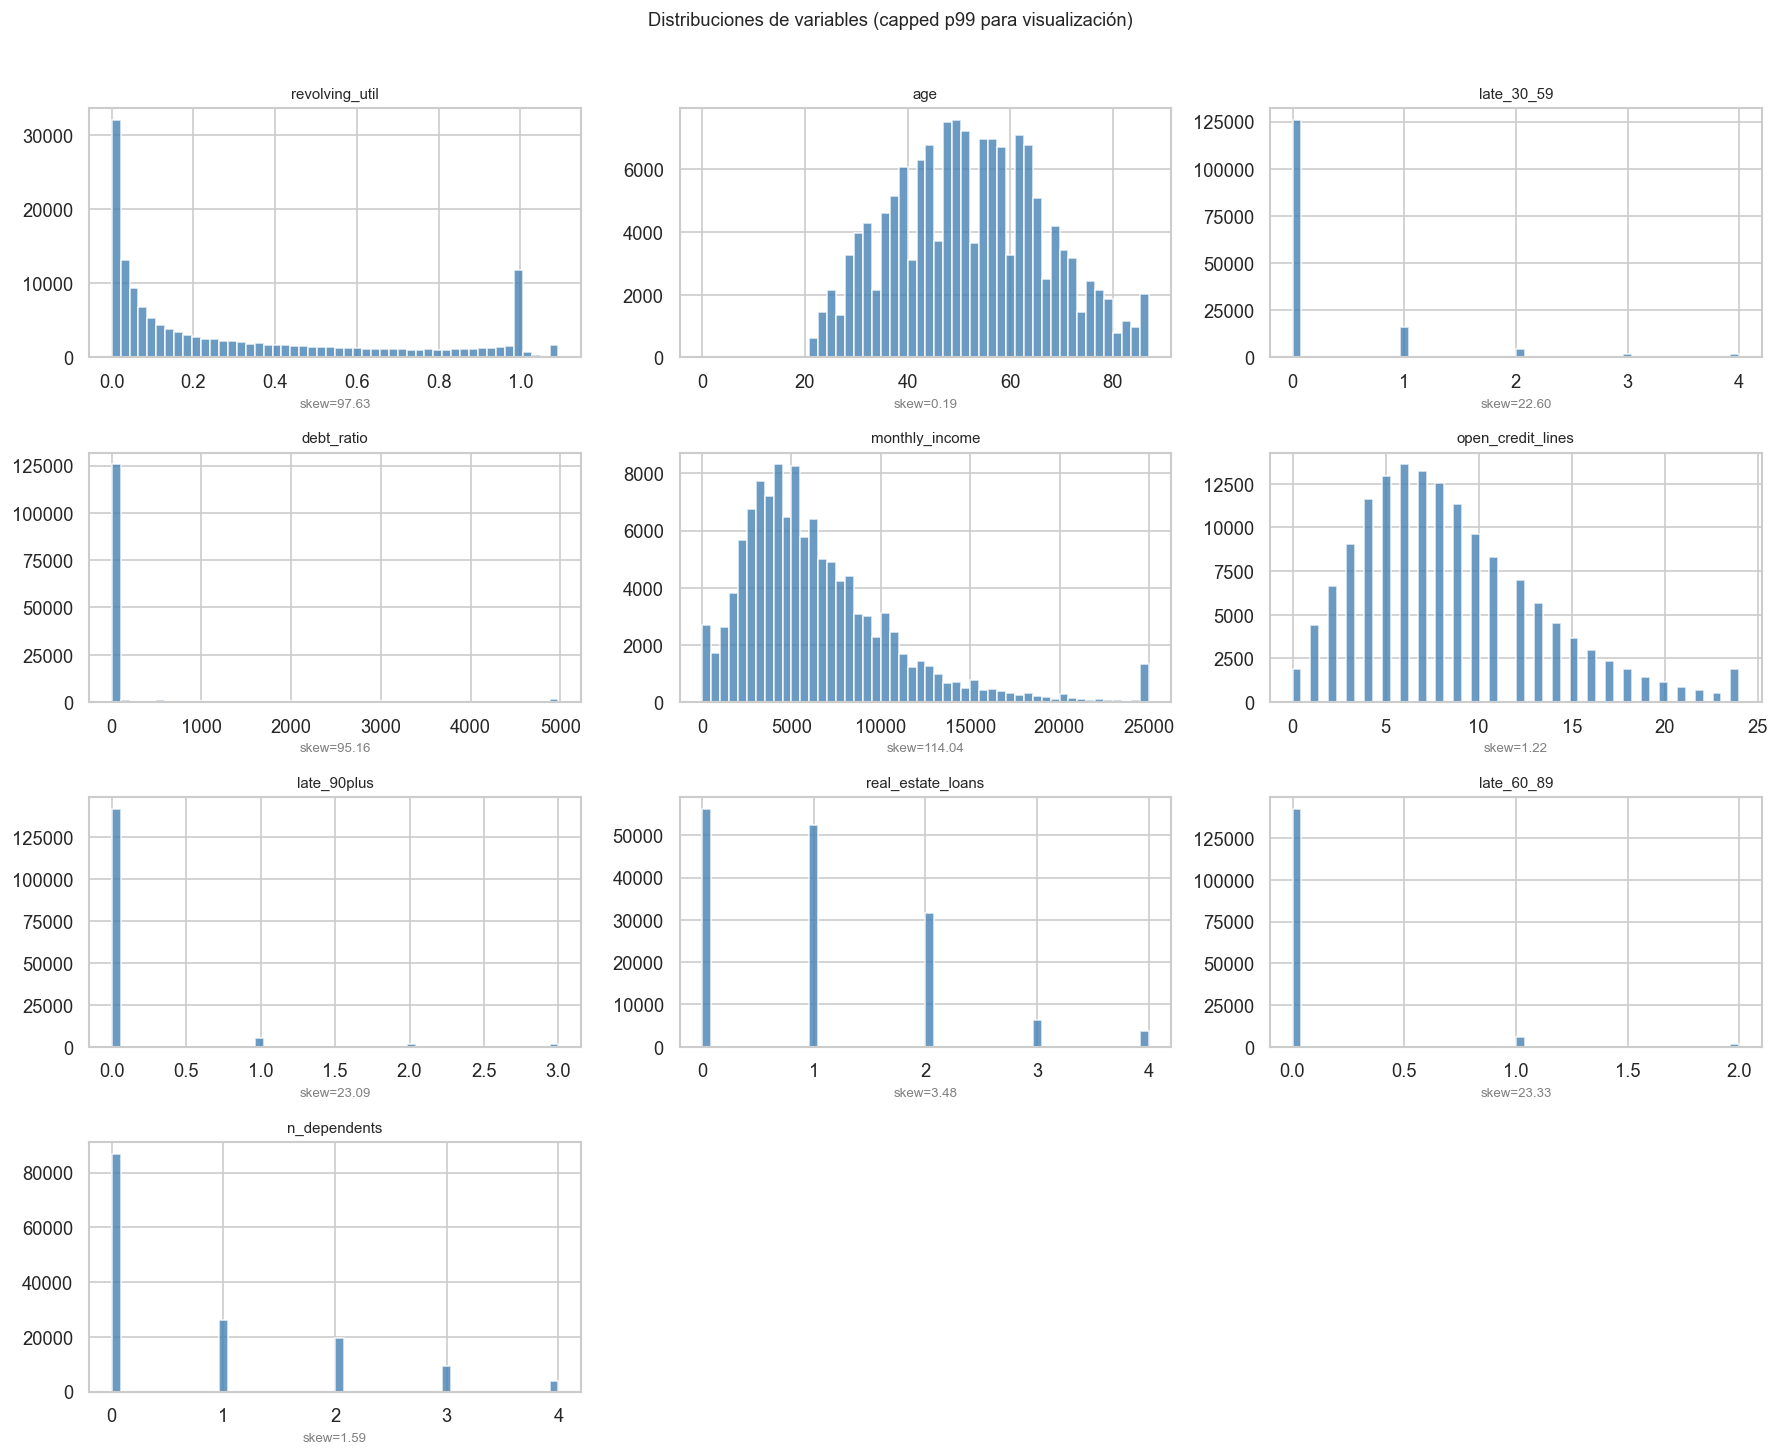

In [8]:
features = [c for c in df.columns if c != 'target']
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = df[feat].dropna()
    # Cap en percentil 99 solo para visualización
    cap = data.quantile(0.99)
    axes[i].hist(data.clip(upper=cap), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    skew = data.skew()
    axes[i].set_xlabel(f'skew={skew:.2f}', fontsize=8, color='gray')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables (capped p99 para visualización)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / '03_feature_distributions.png', bbox_inches='tight')
plt.show()

## 5. Correlaciones entre variables

El heatmap muestra multicolinealidad potencial. Alta correlación entre features puede afectar modelos lineales (scorecard).

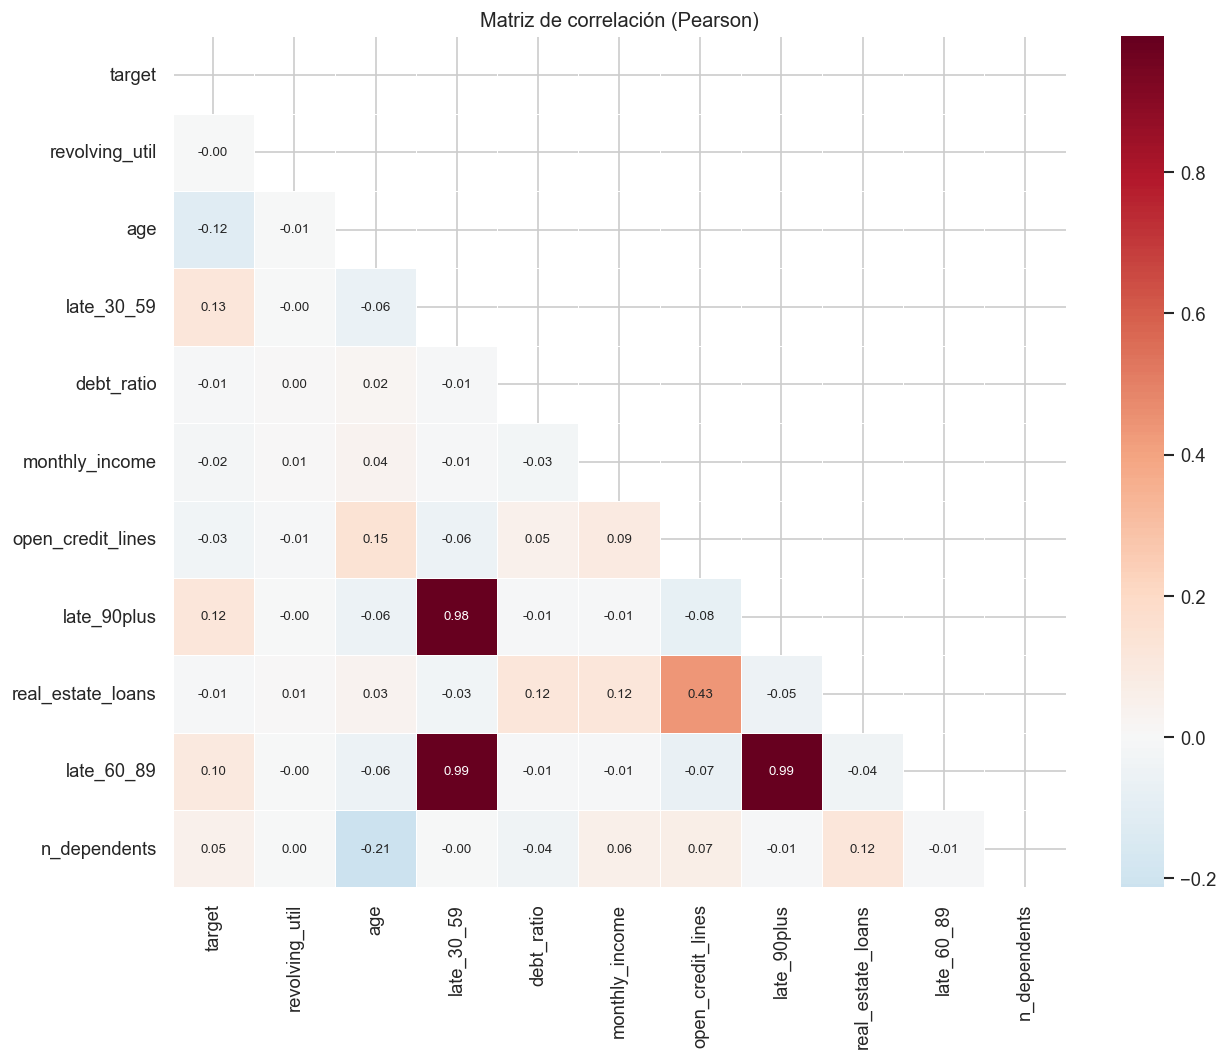

In [9]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlación (Pearson)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Detección de outliers

Usamos IQR y Z-score para cuantificar outliers. Variables con valores físicamente imposibles (ej. `revolving_util > 1`) requieren tratamiento especial.

In [10]:
def outlier_summary(series: pd.Series) -> dict:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_outliers = ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()
    z_outliers = (np.abs(stats.zscore(series.dropna())) > 3).sum()
    return {
        'min': series.min(),
        'max': series.max(),
        'p99': series.quantile(0.99),
        'iqr_outliers': iqr_outliers,
        'iqr_outliers_pct': f'{iqr_outliers / len(series):.1%}',
        'z_outliers': z_outliers,
    }

outlier_df = pd.DataFrame(
    {feat: outlier_summary(df[feat].dropna()) for feat in features}
).T
display(outlier_df)

,min,max,p99,iqr_outliers,iqr_outliers_pct,z_outliers
revolving_util,0.0,50708.0,1.092956,763,0.5%,191
age,0,109,87.0,46,0.0%,46
late_30_59,0,98,4.0,23982,16.0%,270
debt_ratio,0.0,329664.0,4979.04,31311,20.9%,659
monthly_income,0.0,3008750.0,25000.0,4879,4.1%,321
open_credit_lines,0,58,24.0,3980,2.7%,1898
late_90plus,0,98,3.0,8338,5.6%,278
real_estate_loans,0,54,4.0,793,0.5%,1482
late_60_89,0,98,2.0,7604,5.1%,269
n_dependents,0.0,20.0,4.0,13336,9.1%,991


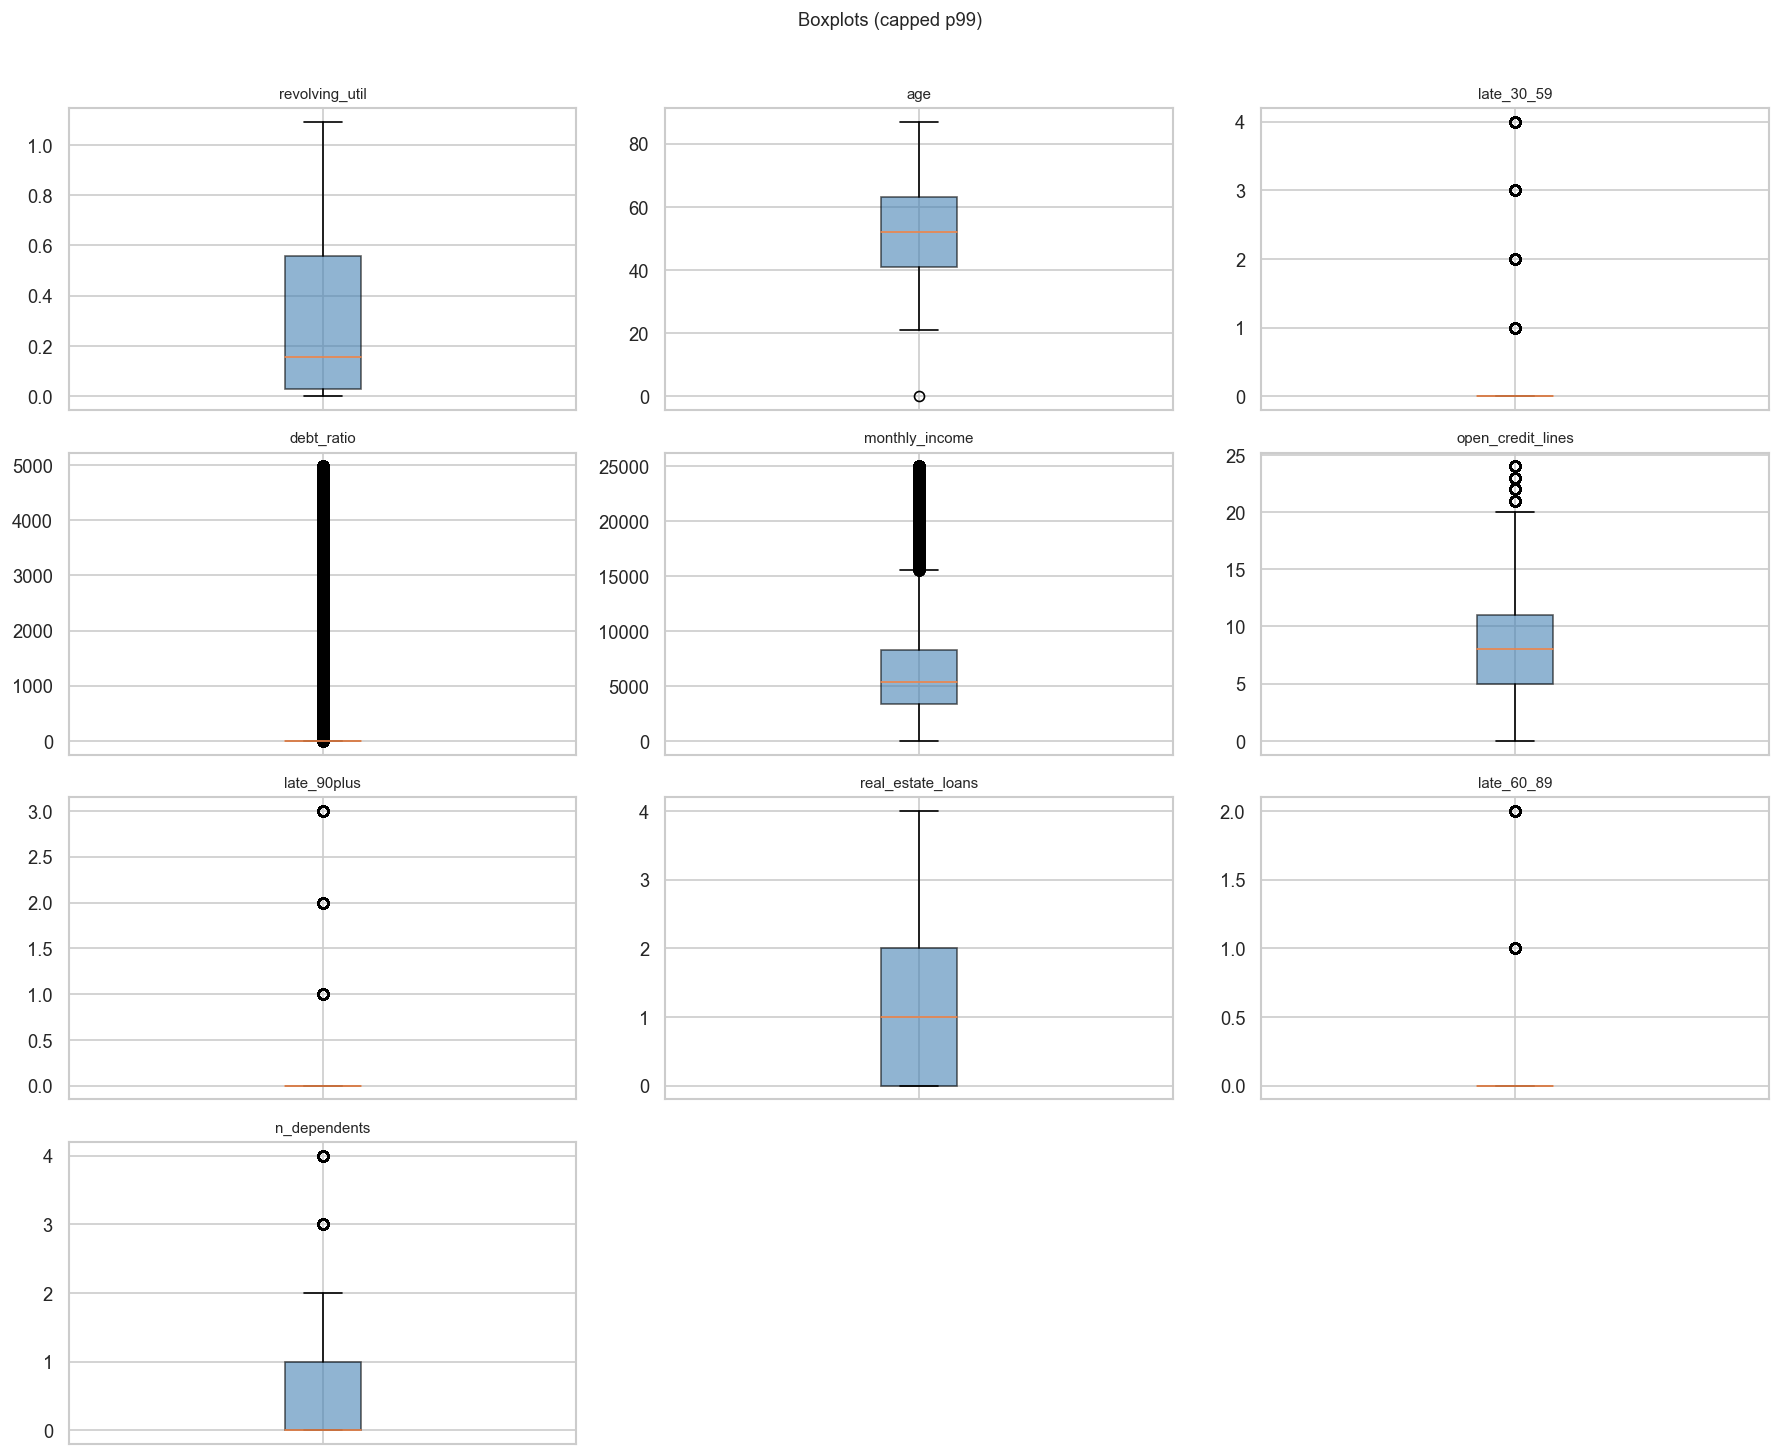

In [11]:
# Boxplots con capping en p99 para visualización
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = df[feat].dropna().clip(upper=df[feat].quantile(0.99))
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xticklabels([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots (capped p99)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / '05_boxplots.png', bbox_inches='tight')
plt.show()

## 7. Análisis bivariado: cada feature vs. target

Comparamos la distribución de cada variable entre clientes que hicieron default (1) y los que no (0). Diferencias grandes indican buen poder predictivo.

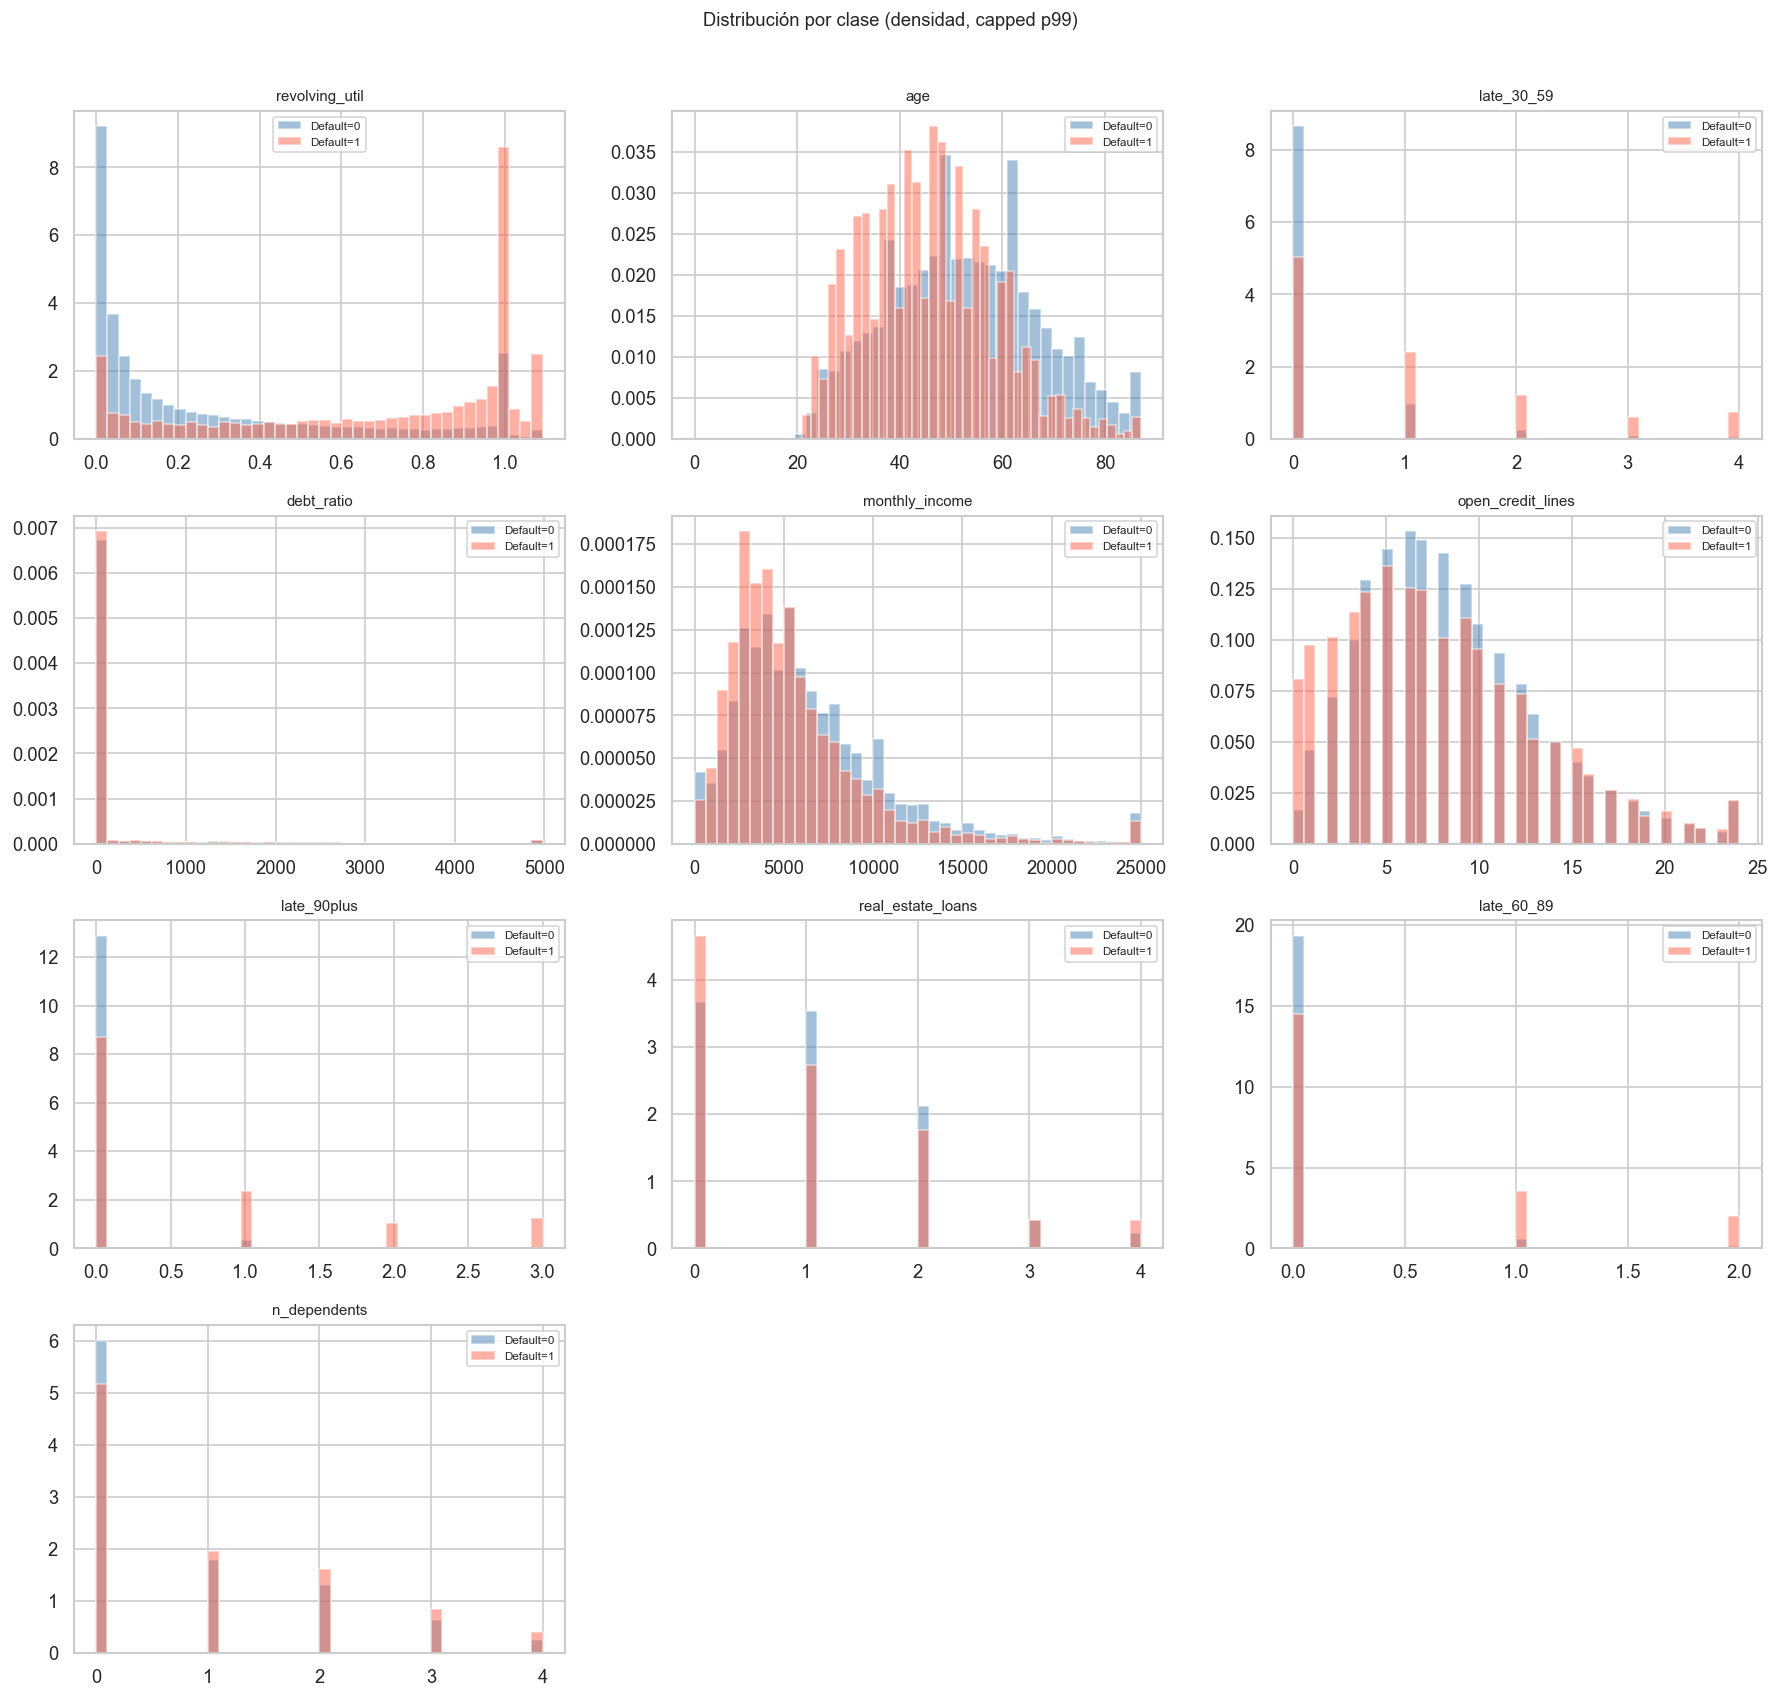

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    cap = df[feat].quantile(0.99)
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = df.loc[df['target'] == label, feat].dropna().clip(upper=cap)
        axes[i].hist(data, bins=40, alpha=0.5, color=color,
                     label=f'Default={label}', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución por clase (densidad, capped p99)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / '06_bivariate_analysis.png', bbox_inches='tight')
plt.show()

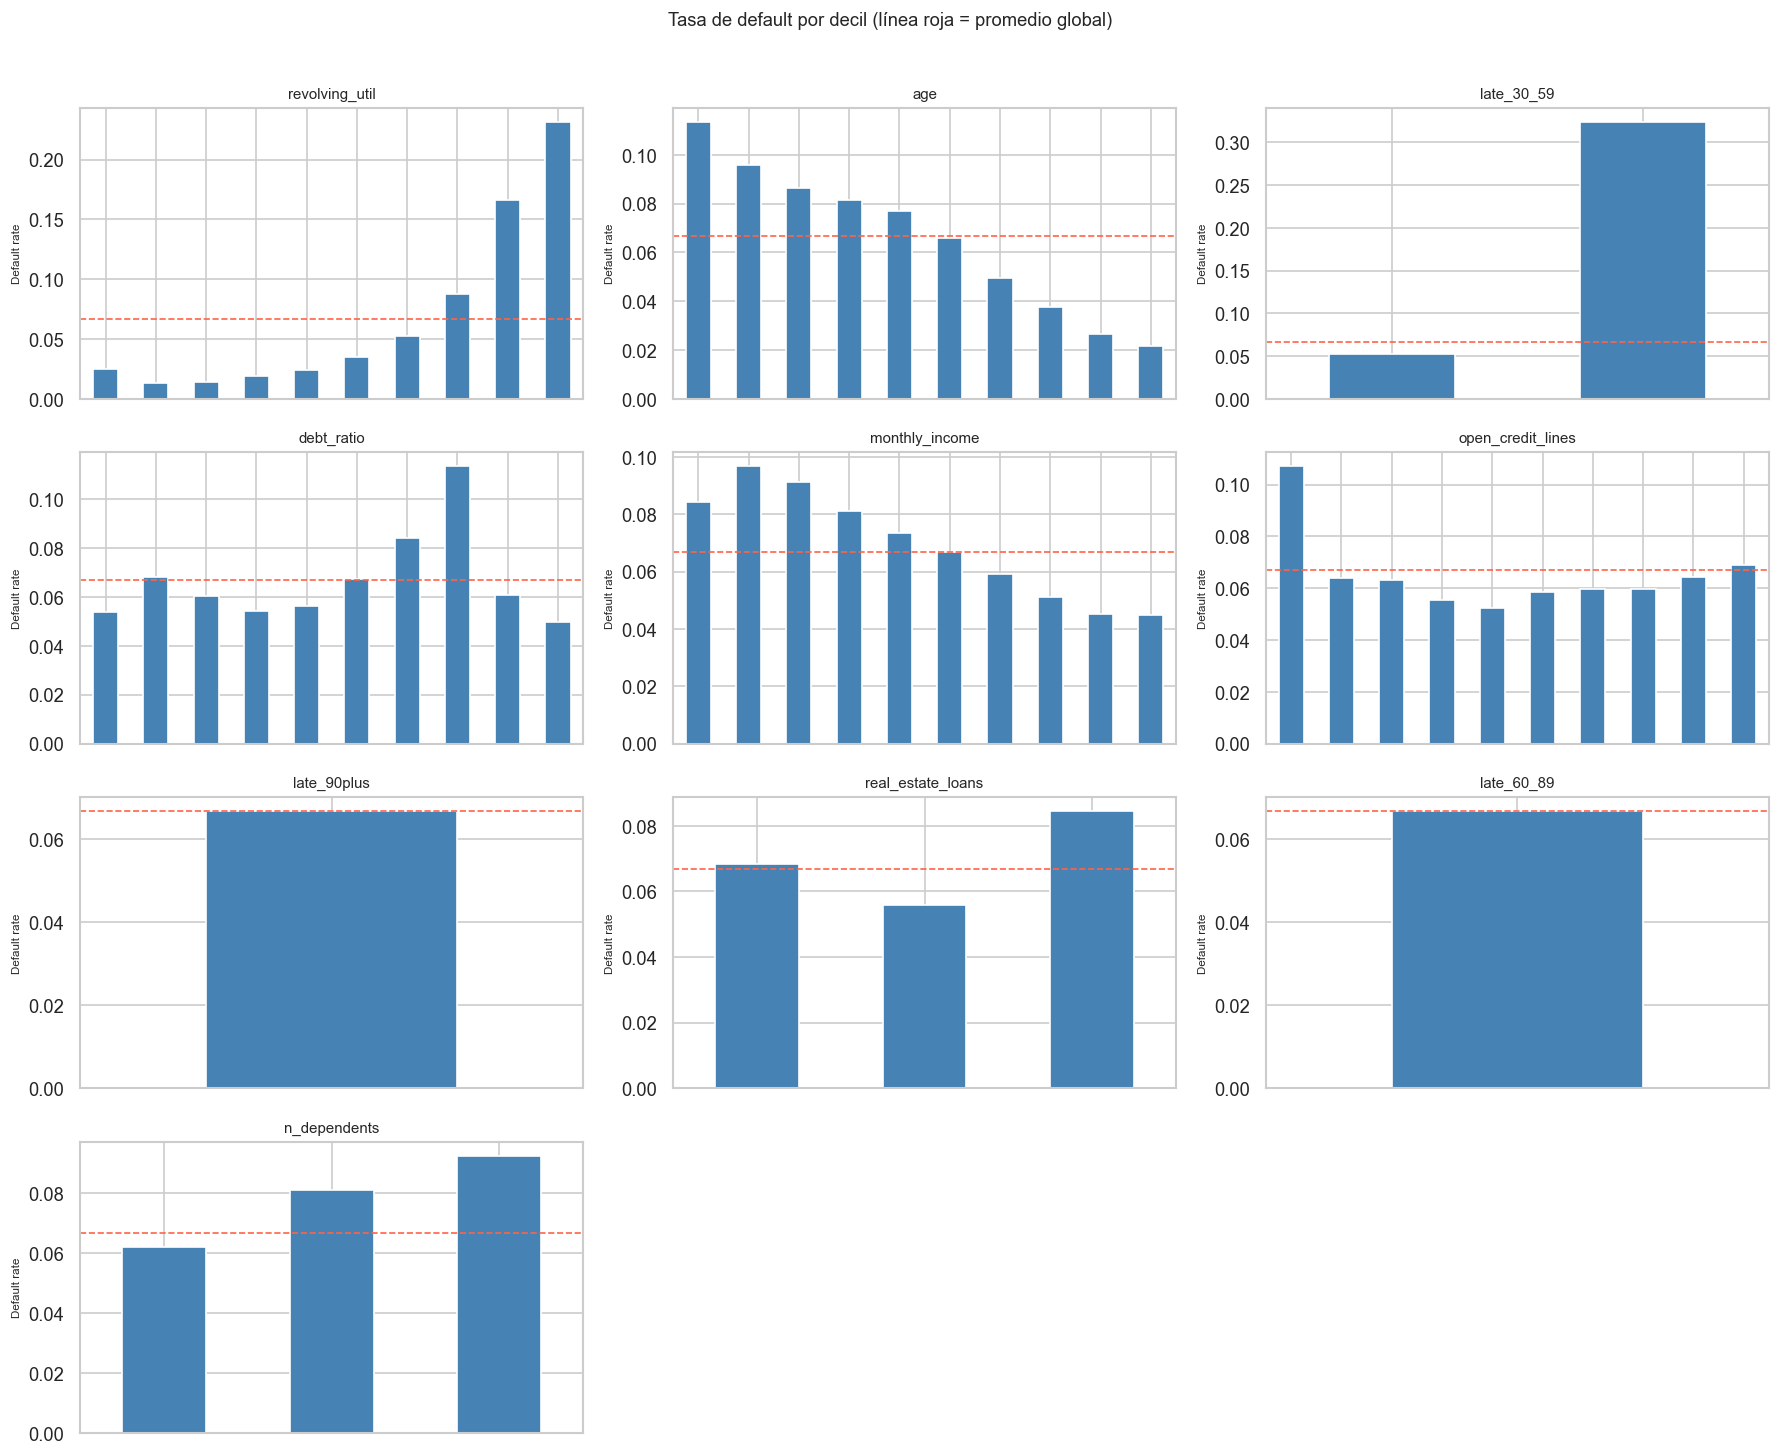

In [13]:
# Tasa de default media por decil de cada variable
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    temp = df[[feat, 'target']].dropna()
    temp['decil'] = pd.qcut(temp[feat].clip(upper=temp[feat].quantile(0.99)),
                            q=10, duplicates='drop')
    default_by_decil = temp.groupby('decil', observed=True)['target'].mean()
    default_by_decil.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels([])
    axes[i].axhline(df['target'].mean(), color='tomato', linestyle='--', linewidth=1)
    axes[i].set_ylabel('Default rate', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de default por decil (línea roja = promedio global)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / '07_default_rate_by_decile.png', bbox_inches='tight')
plt.show()

## 8. Information Value (IV) por variable

El IV mide el poder predictivo de cada variable. Es el estándar en credit scoring bancario:

| IV | Interpretación |
|---|---|
| < 0.02 | Inútil |
| 0.02 – 0.1 | Débil |
| 0.1 – 0.3 | Medio |
| 0.3 – 0.5 | Fuerte |
| > 0.5 | Sospechoso (posible data leakage) |

In [14]:
def calculate_iv(series: pd.Series, target: pd.Series, n_bins: int = 10) -> float:
    """Information Value via decile binning."""
    mask = series.notna()
    s = series[mask].clip(upper=series.quantile(0.99))
    t = target[mask]

    try:
        bins = pd.qcut(s, q=n_bins, duplicates='drop')
    except ValueError:
        bins = pd.cut(s, bins=n_bins)

    total_events = t.sum()
    total_non_events = len(t) - total_events

    grouped = pd.DataFrame({'bin': bins, 'target': t}).groupby('bin', observed=True)['target']
    events = grouped.sum()
    non_events = grouped.count() - events

    dist_events = (events / total_events).replace(0, 1e-6)
    dist_non_events = (non_events / total_non_events).replace(0, 1e-6)

    woe = np.log(dist_events / dist_non_events)
    iv = ((dist_events - dist_non_events) * woe).sum()
    return iv


iv_results = pd.Series(
    {feat: calculate_iv(df[feat], df['target']) for feat in features},
    name='IV'
).sort_values(ascending=False)

def iv_label(iv):
    if iv < 0.02: return 'Inútil'
    if iv < 0.1: return 'Débil'
    if iv < 0.3: return 'Medio'
    if iv < 0.5: return 'Fuerte'
    return 'Sospechoso'

iv_table = iv_results.to_frame().assign(interpretacion=lambda x: x['IV'].map(iv_label))
display(iv_table)

,IV,interpretacion
revolving_util,1.113378,Sospechoso
late_30_59,0.471831,Fuerte
age,0.259158,Medio
monthly_income,0.080386,Débil
debt_ratio,0.073666,Débil
open_credit_lines,0.066892,Débil
n_dependents,0.024085,Débil
real_estate_loans,0.012091,Inútil
late_90plus,0.000000,Inútil
late_60_89,0.000000,Inútil


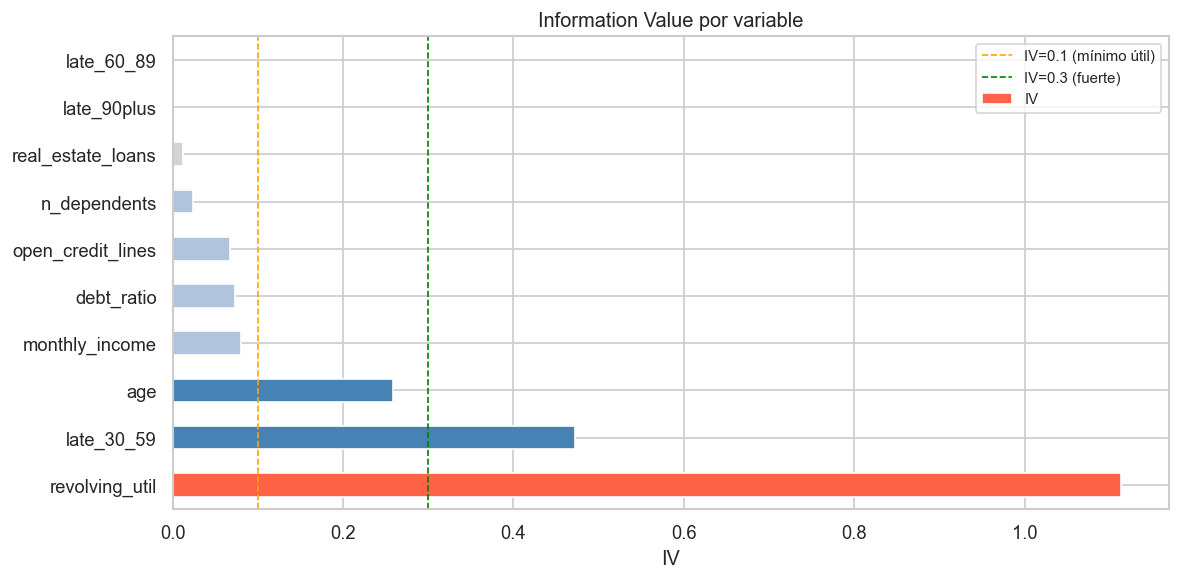


Variables con IV >= 0.1 (candidatas para el modelo):
revolving_util    1.113378
late_30_59        0.471831
age               0.259158


In [15]:
colors = iv_results.map(lambda v: 'tomato' if v > 0.5 else
                                  'steelblue' if v >= 0.1 else
                                  'lightsteelblue' if v >= 0.02 else 'lightgray')

fig, ax = plt.subplots(figsize=(10, 5))
iv_results.plot(kind='barh', ax=ax, color=colors.values, edgecolor='white')
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1, label='IV=0.1 (mínimo útil)')
ax.axvline(0.3, color='green', linestyle='--', linewidth=1, label='IV=0.3 (fuerte)')
ax.set_title('Information Value por variable', fontsize=12)
ax.set_xlabel('IV')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / '08_information_value.png', bbox_inches='tight')
plt.show()

print('\nVariables con IV >= 0.1 (candidatas para el modelo):')
print(iv_results[iv_results >= 0.1].to_string())

## Resumen EDA

**Hallazgos clave para la Fase 2 (Preprocesamiento):**

1. **Nulos:** `monthly_income` (~20%) y `n_dependents` (~3%) requieren imputación
2. **Outliers:** `revolving_util`, `debt_ratio` y atrasos tienen valores extremos — aplicar capping p1/p99
3. **Desbalanceo:** ~6.7% de default — usar `class_weight='balanced'` o SMOTE
4. **Variables predictivas (IV):** ver tabla — las de atrasos y `revolving_util` son las más fuertes
5. **Feature engineering:** crear `total_late_payments`, `income_per_dependent`, `debt_to_income_ratio`

**Próximo paso:** `02_preprocessing_feature_engineering.ipynb`